Using device: cpu

       TRAINING MODEL: CNN + RNN       
Epoch [01/25] | Train Loss: 3.4258 | Val Loss: 3.4298 | Val Acc: 0.00% | Time: 0.33s
Epoch [05/25] | Train Loss: 3.2430 | Val Loss: 3.3033 | Val Acc: 0.00% | Time: 0.01s
Epoch [10/25] | Train Loss: 3.0832 | Val Loss: 3.1568 | Val Acc: 0.00% | Time: 0.02s
Epoch [15/25] | Train Loss: 2.7125 | Val Loss: 2.9291 | Val Acc: 0.00% | Time: 0.01s
Epoch [20/25] | Train Loss: 2.6276 | Val Loss: 2.8097 | Val Acc: 0.00% | Time: 0.01s
Epoch [25/25] | Train Loss: 2.4783 | Val Loss: 2.8212 | Val Acc: 0.00% | Time: 0.01s
--> Final Test Accuracy (CNN+RNN): 0.00%
--> Total Training Time: 0.72 seconds

       TRAINING MODEL: CNN + LSTM       
Epoch [01/25] | Train Loss: 3.4185 | Val Loss: 3.4132 | Val Acc: 0.00% | Time: 0.02s
Epoch [05/25] | Train Loss: 3.3454 | Val Loss: 3.3385 | Val Acc: 0.00% | Time: 0.02s
Epoch [10/25] | Train Loss: 3.2363 | Val Loss: 3.1853 | Val Acc: 0.00% | Time: 0.02s
Epoch [15/25] | Train Loss: 3.0155 | Val Loss: 3.0253 |

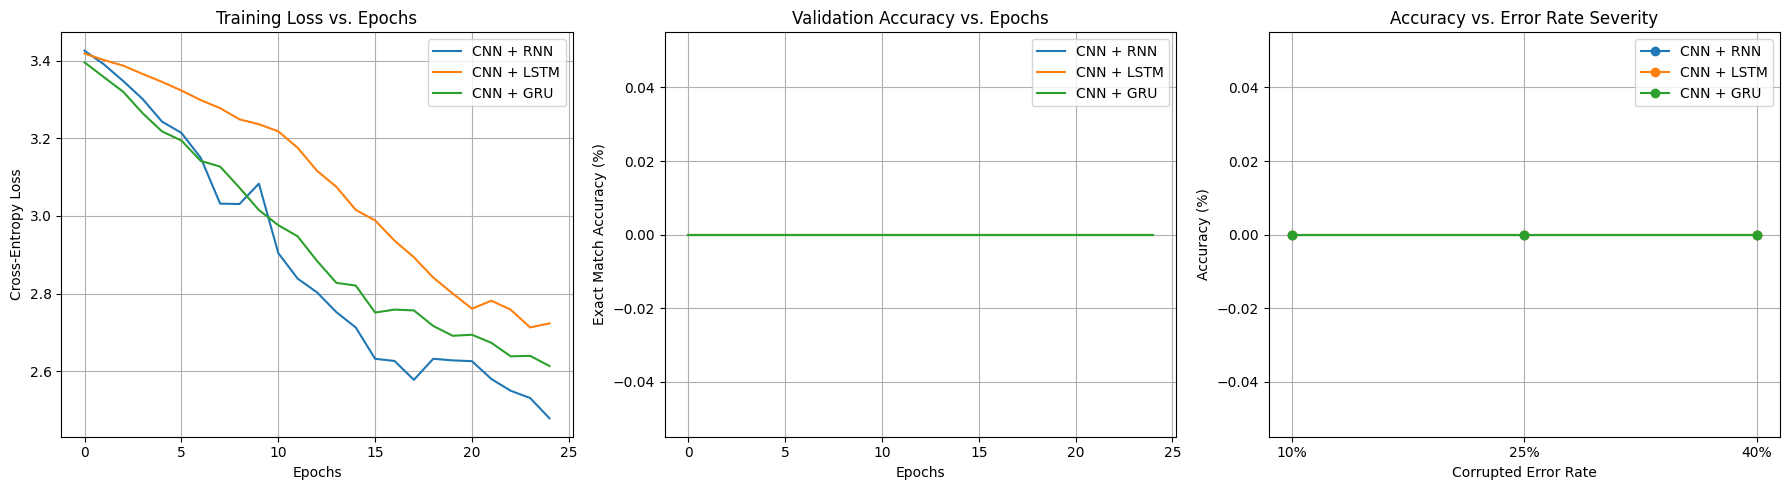

In [1]:
import math
import random
import string
import time
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

# Set random seeds for reproducibility
SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ==========================================
# 1. VOCABULARY & DATASET PREPARATION
# ==========================================
SPECIAL_TOKENS = ["<PAD>", "<SOS>", "<EOS>", "<UNK>"]
ALPHABET = list(string.ascii_lowercase)
CHARS = SPECIAL_TOKENS + ALPHABET
CHAR2IDX = {c: i for i, c in enumerate(CHARS)}
IDX2CHAR = {i: c for i, c in enumerate(CHARS)}
PAD_IDX = CHAR2IDX["<PAD>"]
SOS_IDX = CHAR2IDX["<SOS>"]
EOS_IDX = CHAR2IDX["<EOS>"]
UNK_IDX = CHAR2IDX["<UNK>"]
MAX_LEN = 16  # Fixed sequence length for padded tensors

# Sample dictionary of common English words
BASE_WORDS = [
    "algorithm",
    "architecture",
    "benchmark",
    "character",
    "convolution",
    "correction",
    "decoder",
    "embedding",
    "encoder",
    "experiment",
    "gradient",
    "implementation",
    "learning",
    "network",
    "optimization",
    "performance",
    "recurrent",
    "sequence",
    "synthetic",
    "vocabulary",
    "accuracy",
    "attention",
    "classification",
    "dataset",
    "evaluation",
    "feature",
    "language",
    "machine",
    "pipeline",
    "prediction",
    "representation",
    "spelling",
    "target",
    "training",
    "validation",
]

# Expand base words to create a larger synthetic word bank
RAW_WORDS = list(set(BASE_WORDS * 40))  # ~1400 word dataset instances


def corrupt_word(word, error_rate=0.25):
    """Introduces random typos based on error_rate: insertion, deletion, substitution, swap."""
    word_chars = list(word)
    if len(word_chars) <= 2:
        return word
    num_errors = max(1, int(len(word_chars) * error_rate))
    for _ in range(num_errors):
        op = random.choice(["sub", "del", "ins", "swap"])
        idx = random.randint(0, len(word_chars) - 1)
        if op == "sub":
            word_chars[idx] = random.choice(ALPHABET)
        elif op == "del" and len(word_chars) > 2:
            word_chars.pop(idx)
        elif op == "ins":
            word_chars.insert(idx, random.choice(ALPHABET))
        elif op == "swap" and idx < len(word_chars) - 1:
            word_chars[idx], word_chars[idx + 1] = (
                word_chars[idx + 1],
                word_chars[idx],
            )
    return "".join(word_chars)


class SpellingDataset(Dataset):

    def __init__(self, clean_words, error_rate=0.25):
        self.data = []
        for w in clean_words:
            corrupted = corrupt_word(w, error_rate=error_rate)
            self.data.append((corrupted, w))

    def __len__(self):
        return len(self.data)

    def _encode(self, text, add_sos_eos=False):
        tokens = [CHAR2IDX.get(c, UNK_IDX) for c in text]
        if add_sos_eos:
            tokens = [SOS_IDX] + tokens + [EOS_IDX]
        tokens = tokens[:MAX_LEN]
        tokens += [PAD_IDX] * (MAX_LEN - len(tokens))
        return torch.tensor(tokens, dtype=torch.long)

    def __getitem__(self, idx):
        src_str, trg_str = self.data[idx]
        return self._encode(src_str), self._encode(trg_str, add_sos_eos=True)


# Train/Val/Test Split
random.shuffle(RAW_WORDS)
n_total = len(RAW_WORDS)
train_split = int(0.8 * n_total)
val_split = int(0.9 * n_total)

train_words = RAW_WORDS[:train_split]
val_words = RAW_WORDS[train_split:val_split]
test_words = RAW_WORDS[val_split:]

train_ds = SpellingDataset(train_words)
val_ds = SpellingDataset(val_words)
test_ds = SpellingDataset(test_words)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)


# ==========================================
# 2. MODEL ARCHITECTURES
# ==========================================
class CNN1DEncoder(nn.Module):
    """1D CNN Encoder compressing character sequence to a hidden context vector."""

    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(
            vocab_size, embed_dim, padding_idx=PAD_IDX
        )
        self.conv1d = nn.Conv1d(
            in_channels=embed_dim,
            out_channels=hidden_dim,
            kernel_size=3,
            padding=1,
        )
        self.relu = nn.ReLU()
        self.pool = nn.AdaptiveAvgPool1d(1)

    def forward(self, src):
        # src: (batch_size, seq_len)
        embedded = self.embedding(src).transpose(
            1, 2
        )  # (batch_size, embed_dim, seq_len)
        features = self.relu(
            self.conv1d(embedded)
        )  # (batch_size, hidden_dim, seq_len)
        context = self.pool(features).squeeze(-1)  # (batch_size, hidden_dim)
        return context


class GenericDecoder(nn.Module):
    """Swappable Decoder supporting Vanilla RNN, LSTM, and GRU Cells."""

    def __init__(self, vocab_size, embed_dim, hidden_dim, cell_type="LSTM"):
        super().__init__()
        self.cell_type = cell_type
        self.embedding = nn.Embedding(
            vocab_size, embed_dim, padding_idx=PAD_IDX
        )
        if cell_type == "RNN":
            self.cell = nn.RNNCell(embed_dim, hidden_dim)
        elif cell_type == "LSTM":
            self.cell = nn.LSTMCell(embed_dim, hidden_dim)
        elif cell_type == "GRU":
            self.cell = nn.GRUCell(embed_dim, hidden_dim)
        self.fc_out = nn.Linear(hidden_dim, vocab_size)

    def forward(self, input_token, hidden_state):
        # input_token: (batch_size)
        embedded = self.embedding(input_token)
        if self.cell_type == "LSTM":
            h_next, c_next = self.cell(embedded, hidden_state)
            next_state = (h_next, c_next)
            out_h = h_next
        else:
            h_next = self.cell(embedded, hidden_state)
            next_state = h_next
            out_h = h_next
        output = self.fc_out(out_h)  # (batch_size, vocab_size)
        return output, next_state


class Seq2Seq(nn.Module):
    """Full Seq2Seq system combining Conv1D Encoder + Recurrent Decoder."""

    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        batch_size = src.size(0)
        trg_len = trg.size(1)
        vocab_size = len(CHARS)
        outputs = torch.zeros(batch_size, trg_len, vocab_size).to(src.device)

        context = self.encoder(src)

        # Initialize decoder state with encoder's context vector
        if self.decoder.cell_type == "LSTM":
            hidden_state = (context, torch.zeros_like(context))
        else:
            hidden_state = context

        input_token = trg[:, 0]  # <SOS> token

        for t in range(1, trg_len):
            output, hidden_state = self.decoder(input_token, hidden_state)
            outputs[:, t, :] = output
            teacher_force = random.random() < teacher_forcing_ratio
            top1 = output.argmax(1)
            input_token = trg[:, t] if teacher_force else top1

        return outputs


# ==========================================
# 3. TRAINING & EVALUATION LOGIC
# ==========================================
def train_model(model, train_loader, val_loader, epochs=25, lr=0.001):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
    history = {
        "train_loss": [],
        "val_loss": [],
        "val_acc": [],
        "epoch_times": [],
    }

    start_total_time = time.time()
    for epoch in range(epochs):
        epoch_start = time.time()
        model.train()
        total_train_loss = 0
        for src, trg in train_loader:
            src, trg = src.to(device), trg.to(device)
            optimizer.zero_grad()
            output = model(src, trg, teacher_forcing_ratio=0.5)

            # Flatten output for Loss computation: (B * L, V) vs (B * L)
            loss = criterion(
                output[:, 1:].reshape(-1, len(CHARS)), trg[:, 1:].reshape(-1)
            )
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)
        epoch_end = time.time()

        # Validation Step
        val_loss, val_acc = evaluate(model, val_loader, criterion)
        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["epoch_times"].append(epoch_end - epoch_start)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(
                f"Epoch [{epoch+1:02d}/{epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}% | Time: {epoch_end - epoch_start:.2f}s"
            )

    history["total_time"] = time.time() - start_total_time
    return history


def evaluate(model, data_loader, criterion=None):
    model.eval()
    total_loss = 0
    correct_words = 0
    total_words = 0

    with torch.no_grad():
        for src, trg in data_loader:
            src, trg = src.to(device), trg.to(device)
            output = model(
                src, trg, teacher_forcing_ratio=0.0
            )  # No teacher forcing during inference

            if criterion:
                loss = criterion(
                    output[:, 1:].reshape(-1, len(CHARS)),
                    trg[:, 1:].reshape(-1),
                )
                total_loss += loss.item()

            # Measure Exact-Match Word Accuracy
            predictions = output.argmax(dim=-1)  # (batch_size, max_len)
            for i in range(src.size(0)):
                pred_seq = predictions[i, 1:].tolist()
                target_seq = trg[i, 1:].tolist()

                # Truncate at EOS token if present
                if EOS_IDX in pred_seq:
                    pred_seq = pred_seq[: pred_seq.index(EOS_IDX)]
                if EOS_IDX in target_seq:
                    target_seq = target_seq[: target_seq.index(EOS_IDX)]

                if pred_seq == target_seq:
                    correct_words += 1
                total_words += 1

    avg_loss = total_loss / len(data_loader) if criterion else 0
    accuracy = correct_words / total_words
    return avg_loss, accuracy


def decode_tensor(tensor):
    """Helper function to decode index tensor back to string."""
    chars = []
    for idx in tensor:
        idx_val = idx.item() if isinstance(idx, torch.Tensor) else idx
        if idx_val in [PAD_IDX, SOS_IDX, EOS_IDX]:
            continue
        chars.append(IDX2CHAR.get(idx_val, ""))
    return "".join(chars)


# ==========================================
# 4. EXPERIMENTS EXECUTION
# ==========================================
EMBED_DIM = 64
HIDDEN_DIM = 128
EPOCHS = 25
CELL_TYPES = ["RNN", "LSTM", "GRU"]

histories = {}
trained_models = {}

for cell in CELL_TYPES:
    print(f"\n==========================================")
    print(f"       TRAINING MODEL: CNN + {cell}       ")
    print(f"==========================================")
    encoder = CNN1DEncoder(
        vocab_size=len(CHARS), embed_dim=EMBED_DIM, hidden_dim=HIDDEN_DIM
    )
    decoder = GenericDecoder(
        vocab_size=len(CHARS),
        embed_dim=EMBED_DIM,
        hidden_dim=HIDDEN_DIM,
        cell_type=cell,
    )
    model = Seq2Seq(encoder, decoder).to(device)

    history = train_model(
        model, train_loader, val_loader, epochs=EPOCHS, lr=0.001
    )
    histories[cell] = history
    trained_models[cell] = model

    # Evaluate on Final Test Set
    _, test_acc = evaluate(model, test_loader)
    print(f"--> Final Test Accuracy (CNN+{cell}): {test_acc*100:.2f}%")
    print(f"--> Total Training Time: {history['total_time']:.2f} seconds")

# ==========================================
# 5. ERROR-RATE SENSITIVITY EVALUATION
# ==========================================
print("\n==========================================")
print("   EVALUATION ACROSS VARYING ERROR RATES  ")
print("==========================================")
ERROR_RATES = [0.10, 0.25, 0.40]
error_rate_results = {cell: [] for cell in CELL_TYPES}

for er in ERROR_RATES:
    eval_ds = SpellingDataset(test_words, error_rate=er)
    eval_loader = DataLoader(eval_ds, batch_size=32, shuffle=False)
    print(f"\n--- Testing Noise Level (Error Rate = {int(er*100)}%) ---")

    for cell in CELL_TYPES:
        _, acc = evaluate(trained_models[cell], eval_loader)
        error_rate_results[cell].append(acc * 100)
        print(f"CNN + {cell} Exact Match Acc: {acc*100:.2f}%")

# ==========================================
# 6. GENERATE PERFORMANCE GRAPHS
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Training Loss Curves
for cell in CELL_TYPES:
    axes[0].plot(histories[cell]["train_loss"], label=f"CNN + {cell}")
axes[0].set_title("Training Loss vs. Epochs")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].grid(True)
axes[0].legend()

# Plot 2: Validation Accuracy Curves
for cell in CELL_TYPES:
    axes[1].plot(
        [acc * 100 for acc in histories[cell]["val_acc"]],
        label=f"CNN + {cell}",
    )
axes[1].set_title("Validation Accuracy vs. Epochs")
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Exact Match Accuracy (%)")
axes[1].grid(True)
axes[1].legend()

# Plot 3: Robustness across Error Rates
for cell in CELL_TYPES:
    axes[2].plot(
        [f"{int(er*100)}%" for er in ERROR_RATES],
        error_rate_results[cell],
        marker="o",
        label=f"CNN + {cell}",
    )
axes[2].set_title("Accuracy vs. Error Rate Severity")
axes[2].set_xlabel("Corrupted Error Rate")
axes[2].set_ylabel("Accuracy (%)")
axes[2].grid(True)
axes[2].legend()

plt.tight_layout()
plt.savefig("seq2seq_spelling_performance.png")
print("\nPlots saved successfully as 'seq2seq_spelling_performance.png'")

# ==========================================
# 7. INFERENCE SAMPLES COMPARISON
# ==========================================
print("\n==========================================")
print("       QUALITATIVE EXAMPLE PREDICTIONS    ")
print("==========================================")
sample_src, sample_trg = next(iter(test_loader))
sample_src, sample_trg = sample_src.to(device), sample_trg.to(device)

print(
    f"{'CORRUPTED INPUT':<18} | {'TARGET':<15} | {'RNN':<15} | {'LSTM':<15} | {'GRU':<15}"
)
print("-" * 80)

for cell in CELL_TYPES:
    trained_models[cell].eval()

with torch.no_grad():
    preds = {}
    for cell in CELL_TYPES:
        out = trained_models[cell](
            sample_src, sample_trg, teacher_forcing_ratio=0.0
        )
        preds[cell] = out.argmax(dim=-1)

    for i in range(min(10, sample_src.size(0))):
        src_str = decode_tensor(sample_src[i])
        trg_str = decode_tensor(sample_trg[i])
        rnn_str = decode_tensor(preds["RNN"][i])
        lstm_str = decode_tensor(preds["LSTM"][i])
        gru_str = decode_tensor(preds["GRU"][i])
        print(
            f"{src_str:<18} | {trg_str:<15} | {rnn_str:<15} | {lstm_str:<15} | {gru_str:<15}"
        )

# Summary Runtime Benchmarks Output
print("\n==========================================")
print("           BENCHMARK SUMMARY              ")
print("==========================================")
print(f"{'CELL TYPE':<10} | {'TOTAL TIME (s)':<15} | {'AVG EPOCH TIME (s)':<20}")
print("-" * 50)
for cell in CELL_TYPES:
    t_total = histories[cell]["total_time"]
    t_avg = sum(histories[cell]["epoch_times"]) / EPOCHS
    print(f"{cell:<10} | {t_total:<15.2f} | {t_avg:<20.2f}")

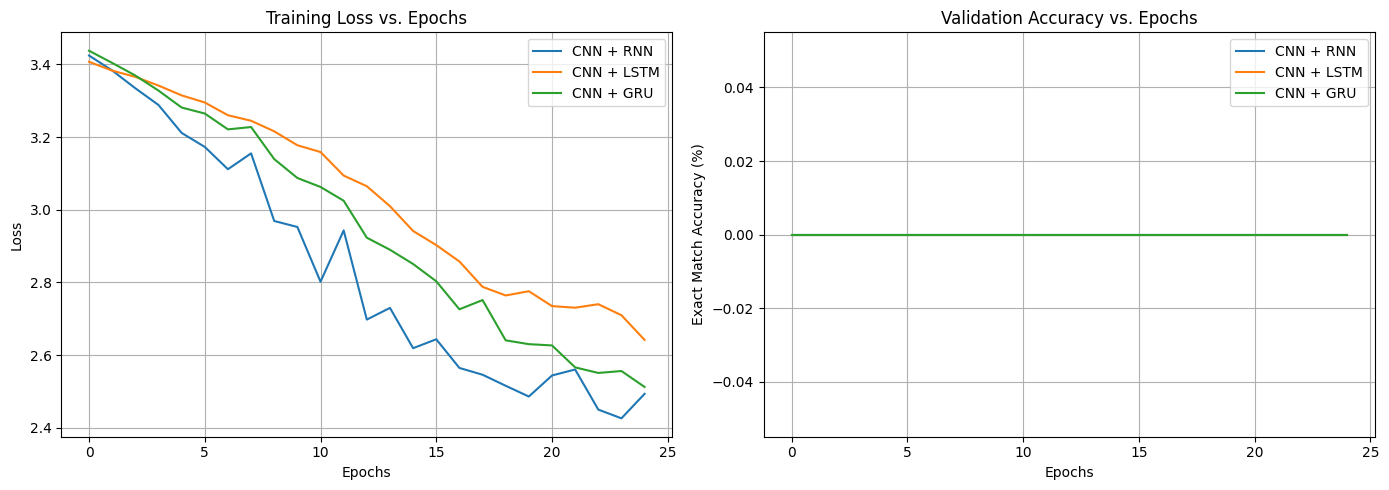

In [ ]:
import random
import string
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

# Set static seeds for reproducibility
SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==============================================================================
# 1. DATA SYNTHESIS & PREPROCESSING
# ==============================================================================
SPECIAL_TOKENS = ["<PAD>", "<SOS>", "<EOS>", "<UNK>"]
ALPHABET = list(string.ascii_lowercase)
CHARS = SPECIAL_TOKENS + ALPHABET

CHAR2IDX = {c: i for i, c in enumerate(CHARS)}
IDX2CHAR = {i: c for i, c in enumerate(CHARS)}

PAD_IDX = CHAR2IDX["<PAD>"]
SOS_IDX = CHAR2IDX["<SOS>"]
EOS_IDX = CHAR2IDX["<EOS>"]
UNK_IDX = CHAR2IDX["<UNK>"]

MAX_LEN = 16  # Fixed length for sequence tensor alignment

BASE_WORDS = [
    "algorithm", "architecture", "benchmark", "character", "convolution",
    "correction", "decoder", "embedding", "encoder", "experiment",
    "gradient", "implementation", "learning", "network", "optimization",
    "performance", "recurrent", "sequence", "synthetic", "vocabulary",
    "accuracy", "attention", "classification", "dataset", "evaluation",
    "feature", "language", "machine", "pipeline", "prediction",
    "representation", "spelling", "target", "training", "validation"
]

RAW_WORDS = list(set(BASE_WORDS * 40))  # Synthetic dataset size (~1400 pairs)

def corrupt_word(word, error_rate=0.25):
    """Applies random synthetic edits: insertion, deletion, substitution, swap."""
    word_chars = list(word)
    if len(word_chars) <= 2:
        return word

    num_errors = max(1, int(len(word_chars) * error_rate))

    for _ in range(num_errors):
        op = random.choice(["sub", "del", "ins", "swap"])
        idx = random.randint(0, len(word_chars) - 1)

        if op == "sub":
            word_chars[idx] = random.choice(ALPHABET)
        elif op == "del" and len(word_chars) > 2:
            word_chars.pop(idx)
        elif op == "ins":
            word_chars.insert(idx, random.choice(ALPHABET))
        elif op == "swap" and idx < len(word_chars) - 1:
            word_chars[idx], word_chars[idx + 1] = word_chars[idx + 1], word_chars[idx]

    return "".join(word_chars)

class SpellingDataset(Dataset):
    def __init__(self, clean_words):
        self.data = [(corrupt_word(w), w) for w in clean_words]

    def __len__(self):
        return len(self.data)

    def _encode(self, text, add_sos_eos=False):
        tokens = [CHAR2IDX.get(c, UNK_IDX) for c in text]
        if add_sos_eos:
            tokens = [SOS_IDX] + tokens + [EOS_IDX]
        tokens = tokens[:MAX_LEN]
        tokens += [PAD_IDX] * (MAX_LEN - len(tokens))
        return torch.tensor(tokens, dtype=torch.long)

    def __getitem__(self, idx):
        src_str, trg_str = self.data[idx]
        return self._encode(src_str), self._encode(trg_str, add_sos_eos=True)

# Dataset Splitting (80% Train, 10% Val, 10% Test)
random.shuffle(RAW_WORDS)
n_total = len(RAW_WORDS)
train_split = int(0.8 * n_total)
val_split = int(0.9 * n_total)

train_ds = SpellingDataset(RAW_WORDS[:train_split])
val_ds = SpellingDataset(RAW_WORDS[train_split:val_split])
test_ds = SpellingDataset(RAW_WORDS[val_split:])

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

# ==============================================================================
# 2. MODEL ARCHITECTURES
# ==============================================================================
class CNN1DEncoder(nn.Module):
    """1D CNN Encoder compressing variable-length character features into context."""
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.conv1d = nn.Conv1d(in_channels=embed_dim, out_channels=hidden_dim, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.AdaptiveAvgPool1d(1)

    def forward(self, src):
        # src: (batch_size, seq_len)
        embedded = self.embedding(src).transpose(1, 2)  # (batch_size, embed_dim, seq_len)
        features = self.relu(self.conv1d(embedded))     # (batch_size, hidden_dim, seq_len)
        context = self.pool(features).squeeze(-1)       # (batch_size, hidden_dim)
        return context

class GenericDecoder(nn.Module):
    """Configurable Recurrent Decoder (RNN, LSTM, or GRU Cell)."""
    def __init__(self, vocab_size, embed_dim, hidden_dim, cell_type="LSTM"):
        super().__init__()
        self.cell_type = cell_type
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)

        if cell_type == "RNN":
            self.cell = nn.RNNCell(embed_dim, hidden_dim)
        elif cell_type == "LSTM":
            self.cell = nn.LSTMCell(embed_dim, hidden_dim)
        elif cell_type == "GRU":
            self.cell = nn.GRUCell(embed_dim, hidden_dim)

        self.fc_out = nn.Linear(hidden_dim, vocab_size)

    def forward(self, input_token, hidden_state):
        embedded = self.embedding(input_token)

        if self.cell_type == "LSTM":
            h_next, c_next = self.cell(embedded, hidden_state)
            next_state = (h_next, c_next)
            out_h = h_next
        else:
            h_next = self.cell(embedded, hidden_state)
            next_state = h_next
            out_h = h_next

        output = self.fc_out(out_h)
        return output, next_state

class Seq2Seq(nn.Module):
    """Unified Seq2Seq Framework with Teacher Forcing Support."""
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        batch_size = src.size(0)
        trg_len = trg.size(1)
        vocab_size = len(CHARS)

        outputs = torch.zeros(batch_size, trg_len, vocab_size).to(src.device)
        context = self.encoder(src)

        if self.decoder.cell_type == "LSTM":
            hidden_state = (context, torch.zeros_like(context))
        else:
            hidden_state = context

        input_token = trg[:, 0]  # <SOS>

        for t in range(1, trg_len):
            output, hidden_state = self.decoder(input_token, hidden_state)
            outputs[:, t, :] = output
            teacher_force = random.random() < teacher_forcing_ratio
            top1 = output.argmax(1)
            input_token = trg[:, t] if teacher_force else top1

        return outputs

# ==============================================================================
# 3. TRAINING & EVALUATION PIPELINE
# ==============================================================================
def train_model(model, train_loader, val_loader, epochs=25, lr=0.001):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
    history = {"train_loss": [], "val_loss": [], "val_acc": []}

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0

        for src, trg in train_loader:
            src, trg = src.to(device), trg.to(device)
            optimizer.zero_grad()

            output = model(src, trg, teacher_forcing_ratio=0.5)
            loss = criterion(output[:, 1:].reshape(-1, len(CHARS)), trg[:, 1:].reshape(-1))
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)
        val_loss, val_acc = evaluate(model, val_loader, criterion)

        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

    return history

def evaluate(model, data_loader, criterion=None):
    model.eval()
    total_loss = 0
    correct_words = 0
    total_words = 0

    with torch.no_grad():
        for src, trg in data_loader:
            src, trg = src.to(device), trg.to(device)
            output = model(src, trg, teacher_forcing_ratio=0.0)

            if criterion:
                loss = criterion(output[:, 1:].reshape(-1, len(CHARS)), trg[:, 1:].reshape(-1))
                total_loss += loss.item()

            predictions = output.argmax(dim=-1)
            for i in range(src.size(0)):
                pred_seq = predictions[i, 1:].tolist()
                target_seq = trg[i, 1:].tolist()

                if EOS_IDX in pred_seq:
                    pred_seq = pred_seq[:pred_seq.index(EOS_IDX)]
                if EOS_IDX in target_seq:
                    target_seq = target_seq[:target_seq.index(EOS_IDX)]

                if pred_seq == target_seq:
                    correct_words += 1
                total_words += 1

    avg_loss = total_loss / len(data_loader) if criterion else 0
    accuracy = correct_words / total_words
    return avg_loss, accuracy

# Executing Comparative Training
EMBED_DIM = 64
HIDDEN_DIM = 128
EPOCHS = 25
CELL_TYPES = ["RNN", "LSTM", "GRU"]

histories = {}
trained_models = {}

for cell in CELL_TYPES:
    encoder = CNN1DEncoder(vocab_size=len(CHARS), embed_dim=EMBED_DIM, hidden_dim=HIDDEN_DIM)
    decoder = GenericDecoder(vocab_size=len(CHARS), embed_dim=EMBED_DIM, hidden_dim=HIDDEN_DIM, cell_type=cell)
    model = Seq2Seq(encoder, decoder).to(device)

    history = train_model(model, train_loader, val_loader, epochs=EPOCHS, lr=0.001)
    histories[cell] = history
    trained_models[cell] = model

# Plot Performance Metrics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for cell in CELL_TYPES:
    axes[0].plot(histories[cell]["train_loss"], label=f"CNN + {cell}")
    axes[1].plot([acc * 100 for acc in histories[cell]["val_acc"]], label=f"CNN + {cell}")

axes[0].set_title("Training Loss vs. Epochs")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Loss")
axes[0].grid(True)
axes[0].legend()

axes[1].set_title("Validation Accuracy vs. Epochs")
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Exact Match Accuracy (%)")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.savefig("seq2seq_spelling_performance.png")